<a href="https://colab.research.google.com/github/Pillapanda/transformer-from-scratch/blob/main/self_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

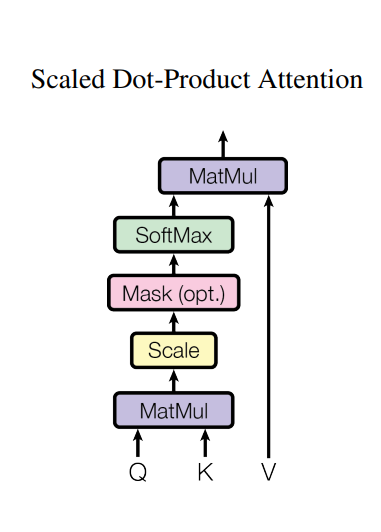

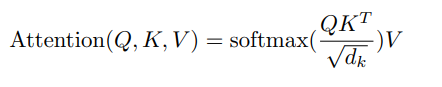

**The input consists of
queries and keys of dimension dk, and values of dimension dv**

In [ ]:
import numpy as np
import math

d_model=512

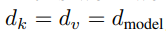

as a sample we take small value

d_k=6,
d_v=6

**I agree with you. That sounds like a good idea**

max_sequence_length=10  

L=10

we take rows=10 and dimensions we take 6 for just ex

In [ ]:
L=10
d_k=6
d_v=6

In [ ]:
q=np.random.randn(L,d_k)
k=np.random.randn(L,d_k)
v=np.random.randn(L,d_v)

In [ ]:
q    ### intialise the sentence

array([[ 1.03128935, -0.12740809,  1.38724779,  0.58359783, -0.7352723 ,
         0.41142195],
       [ 0.38358568,  0.46815529,  1.08105595,  0.07649737,  0.17518289,
        -1.57391511],
       [-0.0999677 ,  0.24339029, -1.60865312, -1.51967508, -0.00606877,
        -0.29545818],
       [-0.08414696,  0.14399598,  0.11512808,  0.02920328, -0.58043513,
        -0.02126188],
       [ 0.65293486,  0.92445354, -0.60404451,  1.20245979,  1.12291236,
        -0.23688608],
       [ 0.75603263,  1.01198301, -2.13974936,  1.87214635, -1.45007307,
        -0.18157058],
       [-0.07274052,  2.06487165, -0.85736345, -0.50250924,  0.57316573,
        -1.03027966],
       [ 0.61767443, -0.84883386,  0.6842073 ,  0.89526084, -0.55906235,
        -0.66462533],
       [-0.57515718,  1.83891908,  0.30878304,  0.49802906,  0.27056396,
        -0.57857943],
       [ 1.66822546, -1.11684824, -0.75476049,  1.74057905, -0.04854405,
        -0.7448155 ]])

In [ ]:
k

array([[-0.90203262,  0.14090839, -0.10916873, -0.3069301 , -0.780389  ,
         2.36584356],
       [ 0.18726163,  0.02673941,  0.22206114, -1.26774878, -0.01991172,
         0.2162127 ],
       [ 0.00741107,  2.26540647,  1.32335631,  0.71872711,  1.19893328,
         0.64134649],
       [ 1.71289534,  0.49059639, -1.11372644,  0.51180336, -1.10292198,
        -3.04285879],
       [-0.61214097, -0.39873324, -0.05936177,  0.4118618 ,  0.69307959,
        -1.08629793],
       [-0.11219552,  1.54621143,  0.97031958,  0.97180475,  0.29586985,
         1.02604644],
       [ 1.08200696,  1.74595284,  0.75054062, -1.20554226,  0.86364673,
         0.90522434],
       [-0.10880896,  1.11488497, -0.0223878 ,  1.15031004,  1.66800305,
         0.68631791],
       [-2.20062241, -0.83543625,  0.12467616, -1.08967235, -0.35342739,
        -0.03312428],
       [ 1.15008254, -0.97191009,  0.08386333,  0.46168286, -1.15927266,
        -1.11449287]])

In [ ]:
v

array([[-1.1622772 , -0.43481985, -1.78432413, -0.37189814, -0.08231657,
         0.58347782],
       [ 0.06601192, -1.77582015,  1.0365135 ,  0.72132336,  0.87988572,
        -0.51199203],
       [ 0.44294358,  1.22420123,  0.07270907, -0.00704472,  0.22495251,
        -0.78638822],
       [-0.31135955, -0.42079837, -1.54711211,  0.92662202,  0.00358753,
        -0.06910216],
       [-0.82889772,  1.67799038, -0.03471181,  0.22785402, -0.01038228,
        -1.13934508],
       [-0.9484851 ,  1.0313993 , -1.19282665,  1.14859313,  1.94857447,
         0.202377  ],
       [-0.28457018,  0.48426814,  0.06183078,  1.07983376, -0.33193152,
         0.99496437],
       [-1.44537039,  0.62258655, -1.04115845, -0.43689896,  1.152654  ,
         0.29164906],
       [ 2.39731647,  1.37566991, -0.26416622, -0.09972109, -0.53136354,
        -0.38438049],
       [ 0.6534969 , -0.00358566, -1.0062246 ,  0.29465426, -1.07428698,
         0.33710082]])

In [ ]:
q.shape

(10, 6)

In [ ]:
k.shape

(10, 6)

In [ ]:
v.shape

(10, 6)

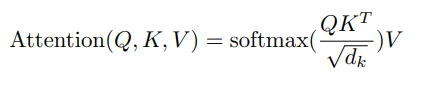

K,Q,V will be generated

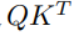

In [ ]:
k.T    ## transpose of K

array([[-0.90203262,  0.18726163,  0.00741107,  1.71289534, -0.61214097,
        -0.11219552,  1.08200696, -0.10880896, -2.20062241,  1.15008254],
       [ 0.14090839,  0.02673941,  2.26540647,  0.49059639, -0.39873324,
         1.54621143,  1.74595284,  1.11488497, -0.83543625, -0.97191009],
       [-0.10916873,  0.22206114,  1.32335631, -1.11372644, -0.05936177,
         0.97031958,  0.75054062, -0.0223878 ,  0.12467616,  0.08386333],
       [-0.3069301 , -1.26774878,  0.71872711,  0.51180336,  0.4118618 ,
         0.97180475, -1.20554226,  1.15031004, -1.08967235,  0.46168286],
       [-0.780389  , -0.01991172,  1.19893328, -1.10292198,  0.69307959,
         0.29586985,  0.86364673,  1.66800305, -0.35342739, -1.15927266],
       [ 2.36584356,  0.2162127 ,  0.64134649, -3.04285879, -1.08629793,
         1.02604644,  0.90522434,  0.68631791, -0.03312428, -1.11449287]])

In [ ]:
o=np.matmul(q,k.T)

In [ ]:
o

array([[ 2.68381062e-01, -1.38492311e-01,  1.35660412e+00,
         1.67066491e-02, -1.37900949e+00,  1.80510405e+00,
         9.68461337e-01, -5.58068075e-01, -2.37977348e+00,
         2.08952767e+00],
       [-4.28188438e+00, -1.16358493e-01,  1.74961539e+00,
         4.31785681e+00,  1.37701176e+00,  2.41062051e-01,
         6.78124866e-01, -2.44005585e-01, -1.19359593e+00,
         1.66316127e+00],
       [ 7.22466568e-02,  1.49337391e+00, -2.86718298e+00,
         1.86772782e+00, -2.49507617e-01, -2.95513567e+00,
         6.68758033e-01, -1.64275471e+00,  1.48397301e+00,
        -8.51718119e-01],
       [ 4.77324698e-01, -1.64037092e-02, -2.10608765e-01,
         5.18105704e-01, -3.79903681e-01,  1.78631121e-01,
        -3.08972571e-01, -7.82049718e-01,  2.53253888e-01,
         4.82989382e-01],
       [-2.19857748e+00, -1.58513965e+00,  3.35834726e+00,
         2.34243212e+00,  7.98402363e-01,  2.02776398e+00,
         1.17292086e+00,  4.06678106e+00, -3.98380351e+00,
        -6.

In [ ]:
o.shape

(10, 10)

In [ ]:
q.var(),k.var(),o.var()  ##variance:a statistical measure of how far a data set is spread out from its mean (average)

(np.float64(0.862165749365433),
 np.float64(1.0847290684329374),
 np.float64(5.225007750686348))

**We suspect that for large values of
dk, the dot products grow large in magnitude, pushing the softmax function into regions where it has
extremely small gradients 4
. To counteract this effect, we scale the dot products by √
1
dk
.**

In [ ]:
scaled=np.matmul(q,k.T)/math.sqrt(d_k)

In [ ]:
scaled

array([[ 1.09566110e-01, -5.65392491e-02,  5.53831311e-01,
         6.82046095e-03, -5.62978266e-01,  7.36930641e-01,
         3.95372685e-01, -2.27830338e-01, -9.71538456e-01,
         8.53046100e-01],
       [-1.74807198e+00, -4.75031558e-02,  7.14277494e-01,
         1.76275766e+00,  5.62162699e-01,  9.84131704e-02,
         2.76843317e-01, -9.96148629e-02, -4.87283497e-01,
         6.78982746e-01],
       [ 2.94945741e-02,  6.09667344e-01, -1.17052255e+00,
         7.62496690e-01, -1.01861058e-01, -1.20642909e+00,
         2.73019324e-01, -6.70651802e-01,  6.05829445e-01,
        -3.47712466e-01],
       [ 1.94866992e-01, -6.69678626e-03, -8.59806683e-02,
         2.11515768e-01, -1.55095028e-01,  7.29258500e-02,
        -1.26137524e-01, -3.19270460e-01,  1.03390467e-01,
         1.97179590e-01],
       [-8.97565498e-01, -6.47130551e-01,  1.37103953e+00,
         9.56293907e-01,  3.25946400e-01,  8.27831179e-01,
         4.78842936e-01,  1.66025642e+00, -1.62638097e+00,
        -2.

In [ ]:
sclaed.var()

np.float64(1.371054362665736)

In [ ]:
q.var(),k.var()

(np.float64(0.862165749365433), np.float64(1.0847290684329374))

**apply softmax**

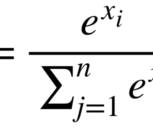

In [ ]:
def softmax(x):
  return (np.exp(x).T / np.sum(np.exp(x),axis=1)).T

In [ ]:
attention=softmax(scaled)

In [ ]:
attention

array([[0.08945618, 0.07576553, 0.13949295, 0.08072136, 0.04565917,
        0.16752178, 0.11905141, 0.06383824, 0.03034538, 0.18814799],
       [0.01044628, 0.05721494, 0.12255939, 0.34970008, 0.10526499,
        0.06620337, 0.0791355 , 0.05430973, 0.0368566 , 0.11830913],
       [0.09457287, 0.16893997, 0.02848431, 0.19683637, 0.08293151,
        0.02747969, 0.1206502 , 0.04695662, 0.16829284, 0.06485562],
       [0.11879825, 0.0971118 , 0.08970971, 0.12079265, 0.08371889,
        0.10516027, 0.08617862, 0.07104328, 0.10841323, 0.1190733 ],
       [0.02147868, 0.02759117, 0.20761096, 0.13712876, 0.07300828,
        0.12059739, 0.08506957, 0.2772398 , 0.01036304, 0.03991235],
       [0.03313877, 0.01188402, 0.02328337, 0.6974418 , 0.02596397,
        0.04567746, 0.01186264, 0.04751074, 0.00616613, 0.09707111],
       [0.01963939, 0.05526968, 0.18458492, 0.26448836, 0.06317548,
        0.07473322, 0.1731435 , 0.11273421, 0.02939209, 0.02283915],
       [0.03295693, 0.0524833 , 0.0437934

In [ ]:
new_v=np.matmul(attention,v)

In [ ]:
new_v

array([[-0.18950278,  0.35122247, -0.65367881,  0.45109376,  0.23274191,
         0.06884266],
       [-0.14835269,  0.26406779, -0.75450647,  0.55349793,  0.09586716,
        -0.12998629],
       [ 0.10138739,  0.09735819, -0.48290017,  0.43143487,  0.05564083,
        -0.06533073],
       [-0.08816977,  0.31850419, -0.63711037,  0.36332158,  0.16808259,
        -0.02846856],
       [-0.52277684,  0.61292423, -0.6794597 ,  0.27413294,  0.54687902,
        -0.05813927],
       [-0.3032483 , -0.16635438, -1.3275636 ,  0.72076949,  0.047472  ,
        -0.01757917],
       [-0.26984429,  0.38545846, -0.60227841,  0.51808808,  0.26677145,
        -0.03557321],
       [ 0.00481799,  0.17238823, -0.87003521,  0.46745249, -0.15440788,
        -0.03384994],
       [-0.25598724,  0.75868416, -0.48720469,  0.33957048,  0.51712713,
        -0.16681834],
       [-0.11426703, -0.08825618, -1.19485691,  0.62903711, -0.19403609,
        -0.00593065]])

# Self attention with multi masked



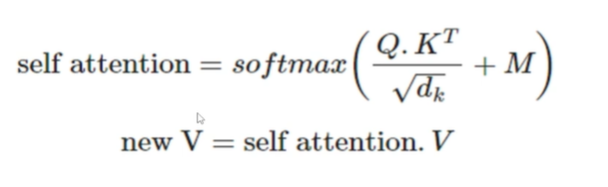

M is masking

In [ ]:
mask=np.tril(np.ones((L,L)))
mask

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])

In [ ]:
mask = np.tril(np.ones((L,L))) # Re-initialize the mask
mask[mask == 0] = -np.inf
mask[mask == 1] = 0

In [ ]:
mask

array([[  0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
       [  0.,   0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
       [  0.,   0.,   0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
       [  0.,   0.,   0.,   0., -inf, -inf, -inf, -inf, -inf, -inf],
       [  0.,   0.,   0.,   0.,   0., -inf, -inf, -inf, -inf, -inf],
       [  0.,   0.,   0.,   0.,   0.,   0., -inf, -inf, -inf, -inf],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0., -inf, -inf, -inf],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., -inf, -inf],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., -inf],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.]])

In [ ]:
scaled=np.matmul(q,k.T)/math.sqrt(d_k)

In [ ]:
sclaed+mask

array([[-1.33501253,        -inf,        -inf,        -inf,        -inf,
               -inf,        -inf,        -inf,        -inf,        -inf],
       [-0.77555614,  0.91532856,        -inf,        -inf,        -inf,
               -inf,        -inf,        -inf,        -inf,        -inf],
       [-0.36716649,  1.05616244,  0.37672402,        -inf,        -inf,
               -inf,        -inf,        -inf,        -inf,        -inf],
       [-1.01634913,  0.70747786,  2.12107289, -1.85466532,        -inf,
               -inf,        -inf,        -inf,        -inf,        -inf],
       [ 0.41083097,  0.67215587, -2.47391875,  0.46917107, -0.99769852,
               -inf,        -inf,        -inf,        -inf,        -inf],
       [-0.73233251,  0.99160384, -0.62805907,  0.35211752,  0.09754969,
         0.67616565,        -inf,        -inf,        -inf,        -inf],
       [ 0.58088107, -0.16976043, -1.04931744, -0.40113679,  0.49222615,
        -1.07522188, -0.82346636,        -inf

In [ ]:
attention=softmax(scaled+mask)

In [ ]:
attention

array([[1.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.15439099, 0.84560901, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.32388285, 0.57856718, 0.09754997, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.27859942, 0.2277415 , 0.2103825 , 0.28327658, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.04601084, 0.05910479, 0.44473655, 0.29375217, 0.15639564,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.03957391, 0.01419175, 0.02780471, 0.83287633, 0.03100585,
        0.05454745, 0.        , 0.        , 0.        , 0.        ],
       [0.02351925, 0.06618849, 0.22105064, 0.31673942, 0.07565613,
        0.08949715, 0.20734891, 0.        , 0.        , 0.        ],
       [0.0519065 , 0.08266013, 0.0689738

In [ ]:
new_v=np.matmul(attention,v)

In [ ]:
new_v

array([[-1.1622772 , -0.43481985, -1.78432413, -0.37189814, -0.08231657,
         0.58347782],
       [-0.12362485, -1.56878179,  0.60100159,  0.55253981,  0.73133036,
        -0.34286135],
       [-0.29504019, -1.04884115,  0.02887346,  0.29619537,  0.50435618,
        -0.18395547],
       [-0.30378939, -0.3872203 , -0.68401845,  0.32167289,  0.22579548,
        -0.13906259],
       [-0.07368107,  0.55830107, -0.44839528,  0.33022188,  0.14769272,
        -0.55163797],
       [-0.36950523, -0.25055622, -1.40857607,  0.83680268,  0.1244401 ,
        -0.08788162],
       [-0.23027677,  0.32923157, -0.54387992,  0.67487375,  0.21194525,
        -0.07766552],
       [-0.49578548,  0.17262505, -0.84603865,  0.59567143,  0.33476865,
        -0.19433553],
       [-0.27591861,  0.77538933, -0.47583036,  0.34055482,  0.55200302,
        -0.17786174],
       [-0.11426703, -0.08825618, -1.19485691,  0.62903711, -0.19403609,
        -0.00593065]])